In [1]:
from pathlib import Path
import pandas as pd
import geopandas as gpd
import numpy as np
import scanpy as sc
import seaborn as sns
import matplotlib.pyplot as plt
import sklearn
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import pairwise_distances
from scipy.stats import spearmanr
from scipy.stats import rankdata
import sys

sys.path.extend(["../../scripts","../../scripts/xenium","../../scripts/xenium/morphology_code"])

import readwrite
from preprocessing import pseudobulk
from regression_utils_r import regress_gene_morphology
from get_embeddings import NorkinOrganoidDataset, get_morphological_features
cfg = readwrite.config()

def compute_correlation(
    adata: sc.AnnData,
    morph_key: str,
    morph_feature_names: list,
    metric: str = 'spearman'
) -> pd.DataFrame:
    """
    Computes the correlation between gene expression and morphological features.

    Args:
        adata (anndata.AnnData):
            The AnnData object containing the gene expression data in .X
            and morphological data in .obsm.
        morph_key (str):
            The key in adata.obsm where the morphological data is stored.
        morph_feature_names (list):
            A list of strings with the names of the morphological features.
        metric (str, optional):
            The correlation metric to use, either 'spearman' or 'pearson'.
            Defaults to 'spearman'.

    Returns:
        pd.DataFrame:
            A DataFrame containing the correlation matrix with genes as rows
            and morphological features as columns.
    """
    # 1. Filter out cells with any NaN values in the morphology data
    valid_cells_mask = ~np.isnan(adata.obsm[morph_key]).any(axis=1)
    adata_filt = adata[valid_cells_mask, :].copy()

    # 2. Extract gene expression matrix (and convert if sparse)
    X = adata_filt.X.copy()
    if not isinstance(X, np.ndarray):
        X = X.toarray()

    # 3. Extract morphological features matrix
    Y = adata_filt.obsm[morph_key].copy()

    # 4. Apply rank transformation for Spearman correlation
    if metric == 'spearman':
        X_processed = rankdata(X, axis=0)
        Y_processed = rankdata(Y, axis=0)
    elif metric == 'pearson':
        # For Pearson, we typically standardize the data
        from sklearn.preprocessing import StandardScaler
        X_processed = StandardScaler().fit_transform(X)
        Y_processed = StandardScaler().fit_transform(Y)
    else:
        raise ValueError(f"Metric '{metric}' is not handled. Use 'spearman' or 'pearson'.")

    # 5. Compute the correlation matrix
    # pairwise_distances with 'correlation' metric computes 1 - Pearson's r.
    # So, we subtract from 1 to get the actual correlation coefficient.
    corr_matrix = 1 - pairwise_distances(X_processed.T, Y_processed.T, metric='correlation')

    # 6. Create a well-labeled DataFrame
    df_corr = pd.DataFrame(
        corr_matrix,
        index=adata_filt.var_names,
        columns=morph_feature_names
    )

    return df_corr


def plot_correlation_clustermap(
    df_corr: pd.DataFrame,
    output_path: str = None,
    top_n_genes: int = None,
    figsize: tuple = (6, 12),
    cmap: str = "vlag",
    **kwargs
) -> sns.matrix.ClusterGrid:
    """
    Plots a clustermap of the gene-morphology correlation matrix.

    Args:
        df_corr (pd.DataFrame):
            The correlation matrix (genes x morphology features).
        output_path (str, optional):
            Path to save the figure. If None, the figure is not saved.
            Defaults to None.
        top_n_genes (int, optional):
            If specified, only the top N genes with the highest absolute
            correlation will be plotted. Defaults to None (all genes).
        figsize (tuple, optional):
            The size of the figure. Defaults to (6, 12).
        cmap (str, optional):
            The colormap for the heatmap. Defaults to "vlag".
        **kwargs:
            Additional keyword arguments passed to sns.clustermap.

    Returns:
        sns.matrix.ClusterGrid:
            The ClusterGrid object for further customization if needed.
    """
    # 1. Optionally, filter for the most variable genes
    if top_n_genes:
        top_genes = df_corr.abs().max(axis=1).sort_values(ascending=False).index[:top_n_genes]
        plot_data = df_corr.loc[top_genes]
    else:
        plot_data = df_corr

    # 2. Plot the clustermap
    sns.set(font_scale=0.8)
    cg = sns.clustermap(
        plot_data,
        cmap=cmap,
        center=0,
        linewidths=0.001,
        figsize=figsize,
        row_cluster=True,
        col_cluster=True,
        **kwargs # Pass any other clustermap arguments
    )

    # 3. Adjust layout and aesthetics
    cg.ax_row_dendrogram.set_visible(False)
    cg.ax_col_dendrogram.set_visible(False)
    
    # Reposition colorbar to be less intrusive
    x0, _y0, _w, _h = cg.cbar_pos
    cg.ax_cbar.set_position([x0 - 0.1, _y0 - 0.2, cg.ax_row_dendrogram.get_position().width - 0.05, 0.02])
    cg.ax_cbar.set_title("Correlation")
    cg.ax_cbar.tick_params(axis='x', length=2)


    # 4. Save the figure if a path is provided
    if output_path:
        p = Path(output_path)
        p.parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(p, bbox_inches='tight', dpi=300)
        print(f"Clustermap saved to: {p}")

    plt.show()

    return cg

def gex_morphology_facet_plot(adata, morph_features, feats, metric='spearman'):
    # Morphology features
    morph_df = pd.DataFrame(
        adata.obsm['morphology'],
        index=adata.obs_names,
        columns=morph_features
    )

    # Gene expression
    expr_df = pd.DataFrame(
        adata[:, feats].X.toarray(),
        columns=feats,
        index=adata.obs_names
    )

    # Combine
    plot_df = pd.concat([expr_df, morph_df], axis=1)

    # Grid dimensions
    n_morphs = len(morph_df.columns)
    n_genes = len(feats)

    fig, axes = plt.subplots(
        nrows=n_morphs,
        ncols=n_genes,
        figsize=(3 * n_genes, 3 * n_morphs),
        sharex=False,
        sharey=False
    )

    # Ensure axes is 2D
    if n_morphs == 1:
        axes = axes[np.newaxis, :]
    if n_genes == 1:
        axes = axes[:, np.newaxis]

    # Plot with regression line and Spearman r
    for i, morph_feat in enumerate(morph_df.columns):   # rows
        for j, gene in enumerate(feats):                # columns
            ax = axes[i, j]

            # Scatter + regression line
            sns.regplot(
                data=plot_df,
                x=gene,
                y=morph_feat,
                scatter_kws={'alpha':0.6, 's':15},
                line_kws={'color':'red'},
                ax=ax
            )

            # Compute Spearman correlation
            rho, pval = spearmanr(plot_df[gene], plot_df[morph_feat])
            ax.text(
                0.05, 0.9, f"ρ={rho:.2f}",
                transform=ax.transAxes,
                fontsize=8,
                color='blue'
            )

            # Axis labels
            if i == n_morphs - 1:
                ax.set_xlabel(gene)
            else:
                ax.set_xlabel('')
            if j == 0:
                ax.set_ylabel(morph_feat)
            else:
                ax.set_ylabel('')

            ax.tick_params(labelsize=6)

    plt.tight_layout()
    plt.show()


/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/.pixi/envs/norkin-organoid/lib/python3.12/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/.pixi/envs/norkin-organoid/lib/python3.12/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/.pixi/envs/norkin-organoid/lib/python3.12/site-packages/anndata/__ini

## Parameters

In [8]:
scale_masks = False
standardize_scale_masks = False
correction_method = 'raw'
segmentation = 'proseg_expected'
organoid_id_column_key='component_and_cluster_and_lasso'
path_h5ad = cfg['results_dir']+f"xenium/integration/{correction_method}/{segmentation}/adata_malignant.h5ad"
path_morphology_pkl = cfg['results_dir']+f"xenium/segment_organoids/proseg_expected_organoids_morphology_{standardize_scale_masks=}_{scale_masks=}"
path_morphology = cfg['results_dir']+f"xenium/segment_organoids/proseg_expected_organoids_morphology_{standardize_scale_masks=}_{scale_masks=}.parquet"
path_organoid_ids = cfg['results_dir']+"xenium/segment_organoids/organoids_ids.parquet"

# Read morphology results

In [9]:
# morphology per organoid
if not Path(path_morphology).exists():
    dataset = NorkinOrganoidDataset(
        organoid_cell_mapping_path=path_organoid_ids,
        organoid_id_column_key=organoid_id_column_key,
        standardize_scale=standardize_scale_masks, 
        scale=scale_masks, 
        fill=True,
        use_cached_adata=False,
        adata_save_pth=cfg['results_dir']+f'xenium/segment_organoids/ads_{scale_masks=}.pkl',
        save_path=path_morphology_pkl,
        )
    masks = [dataset[idx].squeeze() for idx in range(len(dataset))]
    morph = get_morphological_features(masks)
    df_morph = pd.DataFrame(morph,index=dataset.organoid_ids)
    df_morph.to_parquet(path_morphology)
else:
    df_morph = pd.read_parquet(path_morphology)

# organoid IDs per cell
gdf = gpd.read_parquet(path_organoid_ids)
gdf = gdf.join(df_morph,on=organoid_id_column_key).dropna()


# distance of cells to centroid of their organoid
mode = 'approx'

if mode == 'exact':
    # Group by the cluster labels and calculate the centroid for each group.
    # Calculate the distance of each shape to the centroid of its cluster.
    cluster_centroids = gdf.groupby('component_and_cluster_and_lasso')['geometry'].transform(lambda x: x.union_all().centroid)
    distance_to_centroid = gdf['geometry'].distance(cluster_centroids)
    gdf['distance_to_centroid'] = distance_to_centroid
elif mode == 'approx':
    gdf['shape_centroid'] = gdf['geometry'].centroid
    # Group by cluster labels and calculate the "centroid of centroids" for each group
    # Calculate the distance from each shape's centroid to the cluster's centroid of centroids
    cluster_centroid_of_centroids = gdf.groupby('component_and_cluster_and_lasso')['shape_centroid'].transform(lambda x: x.union_all().centroid)

    distance_to_centroid_approx = gdf['shape_centroid'].distance(cluster_centroid_of_centroids)
    gdf['distance_to_centroid_approx'] = distance_to_centroid_approx

/tmp/ipykernel_3668284/1736257046.py:35: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf['shape_centroid'] = gdf['geometry'].centroid
/tmp/ipykernel_3668284/1736257046.py:40: UserWarning: Geometry is in a geographic CRS. Results from 'distance' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  distance_to_centroid_approx = gdf['shape_centroid'].distance(cluster_centroid_of_centroids)
/tmp/ipykernel_3668284/1736257046.py:40: UserWarning: CRS mismatch between the CRS of left geometries and the CRS of right geometries.
Use `to_crs()` to reproject one of the input geometries to match the CRS of the other.

Left CRS: EPSG:4326
Right CRS: None

  distance_to_centroid_approx = gdf['shape_centroid'].distance(cluster_centroid_of_centroids)


# Read H&E results

In [75]:
def _reshape_df(df,k):
    df = df.groupby(k)['morphological_features'].mean()
    return pd.DataFrame(df.tolist(),index=df.index)

df_he = pd.read_parquet('/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/lmcconn1/norkin_organoid/data/organoids_h&e/all_data.parquet')

df_he_sc = _reshape_df(df_he,'full_cell_id')
df_he_pb = _reshape_df(df_he,'organoid_id')
df_he_tiles = _reshape_df(df_he,['organoid_id','tissue_id','tile_id'])

# Read GEX

In [ ]:
# gene expression
adata_malignant = sc.read(path_h5ad)
adata_malignant_PDO = adata_malignant[adata_malignant.obs["condition"] != "CRC"].copy()

# add morphology info to single cell level adata
adata_malignant_PDO.obs = adata_malignant_PDO.obs.join(gdf,on=['full_id'],rsuffix='_y',how='left')

# add he info to single cell level adata
adata_malignant_PDO.obs = adata_malignant_PDO.obs.join(df_he_sc,on=['full_id'],rsuffix='_y',how='left').dropna()

adata_malignant_PDO.obsm["morphology"] = sklearn.preprocessing.StandardScaler().fit_transform(adata_malignant_PDO.obs[df_morph.columns].values)

/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/.pixi/envs/norkin-organoid/lib/python3.12/site-packages/anndata/_core/anndata.py:1774: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [ ]:
# df_= adata_malignant_PDO.obs.set_index('full_id').dropna()
# df_ = df_[df_.columns.difference(['geometry','shape_centroid'])]
# df_.to_parquet('../../scratch/cells_passing_QC_morphology.parquet')

# plot morphological features

In [ ]:
melted = df_morph.melt(var_name="feature", value_name="value")
g = sns.FacetGrid(melted, col="feature", col_wrap=3, sharex=False, sharey=False, height=3)
g.map(sns.histplot, "value", bins=30)

plt.tight_layout()
plt.show()


# === PCA analysis ===
X_morph_scaled = StandardScaler().fit_transform(df_morph.values)
skpca = PCA()
X_morph_pca = skpca.fit_transform(X_morph_scaled)

# === Explained variance ===
explained_var = skpca.explained_variance_ratio_ * 100  # in %
cum_explained_var = np.cumsum(explained_var)

# --- Plot 1: Explained variance per component ---
plt.figure(figsize=(8, 4))
plt.bar(range(1, len(explained_var) + 1), explained_var, alpha=0.7)
plt.plot(range(1, len(cum_explained_var) + 1), cum_explained_var, marker='o', color='black')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance (%)')
plt.title('Explained Variance by Principal Components')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# --- Plot 2: PCA scatter plot (PC1 vs PC2) ---
plt.figure(figsize=(6, 6))
plt.scatter(X_morph_pca[:, 0], X_morph_pca[:, 1], alpha=0.7)
plt.xlabel(f'PC1 ({explained_var[0]:.2f}% var)')
plt.ylabel(f'PC2 ({explained_var[1]:.2f}% var)')
plt.title('PCA: PC1 vs PC2')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# === Feature (gene) loadings ===
loadings = pd.DataFrame(
    skpca.components_.T,
    columns=[f'PC{i+1}' for i in range(skpca.n_components_)],
    index=df_morph.columns
)

# --- Extract top contributing features per PC ---
n_top = 20  # number of top features to show
for i in range(3):  # for first 3 PCs
    pc_name = f'PC{i+1}'
    sorted_loadings = loadings[pc_name].abs().sort_values(ascending=False)
    top_genes = sorted_loadings.head(n_top).index
    print(f"\n🔹 Top {n_top} contributing genes for {pc_name}:")
    print(loadings.loc[top_genes, pc_name].sort_values(ascending=False))

    # --- Plot 3: barplot of top gene loadings per PC ---
    plt.figure(figsize=(8, 4))
    loadings.loc[top_genes, pc_name].sort_values().plot(kind='barh')
    plt.title(f'Top {n_top} Genes Contributing to {pc_name}')
    plt.xlabel('Loading Weight')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()


# Spearman correlation
corr = df_morph.corr(method='spearman')

# Mask upper triangle for a clean half-matrix heatmap
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr, 
    mask=mask, 
    cmap="coolwarm", 
    center=0,
    annot=False, 
    fmt=".2f",
    linewidths=0.5,
    cbar_kws={"label": "Spearman correlation"}
)
plt.title("Spearman Correlation Between Morphology Features")
plt.tight_layout()
plt.show()

# Compute the rank-transformed data (so pairplot reflects Spearman relationships)
df_ranked = df_morph.rank()

# Create the pairplot
sns.pairplot(
    df_ranked,
    kind="scatter",
    plot_kws=dict(alpha=0.6, s=20, edgecolor="none"),
    diag_kind="hist",
    corner=True  # show only lower triangle
)

plt.suptitle("Pairwise Spearman Relationships Between Morphology Features", y=1.02)
plt.tight_layout()
plt.show()

# plot HE features

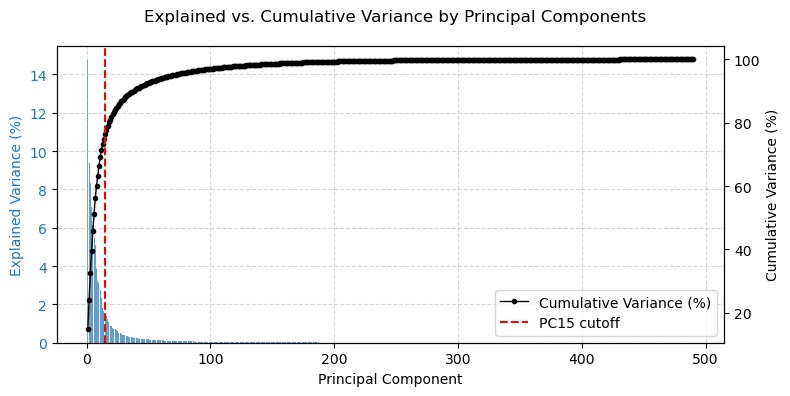

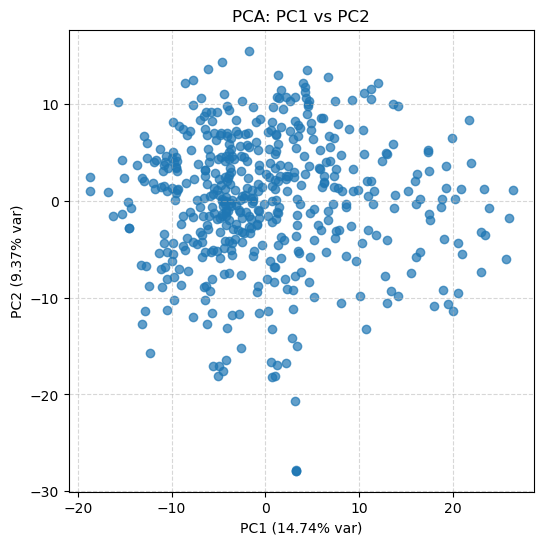


🔹 Top 20 contributing genes for PC1:
499    0.094871
199    0.089740
241    0.087424
17     0.083660
175    0.083022
474    0.081563
161    0.081098
412    0.081044
437    0.079426
371   -0.079735
496   -0.080192
31    -0.080838
488   -0.083680
511   -0.087046
461   -0.087365
171   -0.088229
285   -0.088454
48    -0.089875
320   -0.092658
471   -0.093849
Name: PC1, dtype: float64


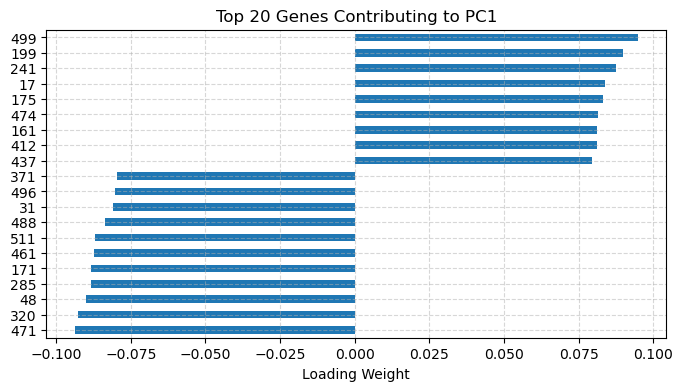


🔹 Top 20 contributing genes for PC2:
235    0.112451
3      0.110258
138    0.104597
353    0.101599
305    0.099406
364    0.099136
420    0.098513
390    0.097410
310    0.094223
55     0.093068
5      0.090106
4      0.089200
399    0.088831
131   -0.091993
317   -0.094182
93    -0.096122
226   -0.098386
123   -0.099023
379   -0.099951
432   -0.106546
Name: PC2, dtype: float64


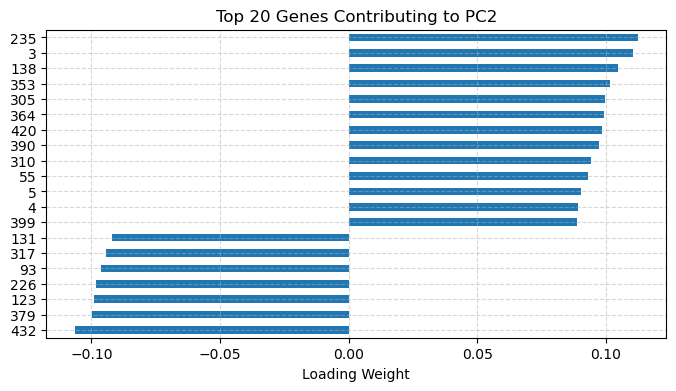


🔹 Top 20 contributing genes for PC3:
132    0.115483
233    0.105584
153    0.098633
188    0.097787
315    0.092405
167    0.090839
368    0.090831
185    0.090555
110   -0.090674
237   -0.091630
168   -0.092626
143   -0.095435
415   -0.096122
76    -0.099310
356   -0.101881
42    -0.104398
393   -0.104949
135   -0.106643
270   -0.108078
85    -0.111663
Name: PC3, dtype: float64


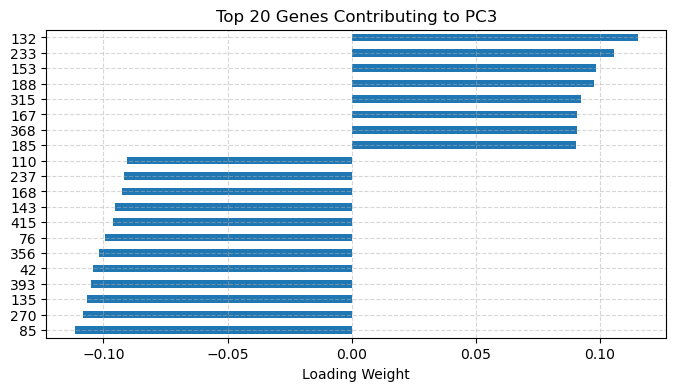

In [101]:
# melted = df_he_pb.melt(var_name="feature", value_name="value")
# g = sns.FacetGrid(melted, col="feature", col_wrap=3, sharex=False, sharey=False, height=3)
# g.map(sns.histplot, "value", bins=30)

# plt.tight_layout()
# plt.show()


# === PCA analysis ===
X_morph_scaled = StandardScaler().fit_transform(df_he_pb.values)
skpca = PCA()
X_morph_pca = skpca.fit_transform(X_morph_scaled)

# === Explained variance ===
explained_var = skpca.explained_variance_ratio_ * 100  # in %
cum_explained_var = np.cumsum(explained_var)

n_pcs_to_keep = np.where((explained_var < (explained_var[0]/10)))[0].min()

# --- Plot 1: Explained variance per component ---
fig, ax1 = plt.subplots(figsize=(8, 4))

# --- Bar plot (left y-axis) ---
ax1.bar(range(1, len(explained_var) + 1), explained_var, alpha=0.7, label='Explained Variance (%)')
ax1.set_xlabel('Principal Component')
ax1.set_ylabel('Explained Variance (%)', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.grid(True, linestyle='--', alpha=0.5)

# --- Line plot (right y-axis) ---
ax2 = ax1.twinx()
ax2.plot(range(1, len(cum_explained_var) + 1), cum_explained_var,
         marker='o', color='black', label='Cumulative Variance (%)',lw=1,markersize=3)
ax2.axvline(n_pcs_to_keep + 1, color='red', linestyle='--', label=f'PC{n_pcs_to_keep + 1} cutoff')
ax2.set_ylabel('Cumulative Variance (%)', color='black')
ax2.tick_params(axis='y', labelcolor='black')

# --- Title and legend ---
fig.suptitle('Explained vs. Cumulative Variance by Principal Components')
fig.tight_layout()
plt.legend()
plt.show()

# --- Plot 2: PCA scatter plot (PC1 vs PC2) ---
plt.figure(figsize=(6, 6))
plt.scatter(X_morph_pca[:, 0], X_morph_pca[:, 1], alpha=0.7)
plt.xlabel(f'PC1 ({explained_var[0]:.2f}% var)')
plt.ylabel(f'PC2 ({explained_var[1]:.2f}% var)')
plt.title('PCA: PC1 vs PC2')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# === Feature (gene) loadings ===
loadings = pd.DataFrame(
    skpca.components_.T,
    columns=[f'PC{i+1}' for i in range(skpca.n_components_)],
    index=df_he_pb.columns
)

# --- Extract top contributing features per PC ---
n_top = 20  # number of top features to show
for i in range(3):  # for first 3 PCs
    pc_name = f'PC{i+1}'
    sorted_loadings = loadings[pc_name].abs().sort_values(ascending=False)
    top_genes = sorted_loadings.head(n_top).index
    print(f"\n🔹 Top {n_top} contributing genes for {pc_name}:")
    print(loadings.loc[top_genes, pc_name].sort_values(ascending=False))

    # --- Plot 3: barplot of top gene loadings per PC ---
    plt.figure(figsize=(8, 4))
    loadings.loc[top_genes, pc_name].sort_values().plot(kind='barh')
    plt.title(f'Top {n_top} Genes Contributing to {pc_name}')
    plt.xlabel('Loading Weight')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()


# # Spearman correlation
# corr = df_morph.corr(method='spearman')

# # Mask upper triangle for a clean half-matrix heatmap
# mask = np.triu(np.ones_like(corr, dtype=bool))

# plt.figure(figsize=(10, 8))
# sns.heatmap(
#     corr, 
#     mask=mask, 
#     cmap="coolwarm", 
#     center=0,
#     annot=False, 
#     fmt=".2f",
#     linewidths=0.5,
#     cbar_kws={"label": "Spearman correlation"}
# )
# plt.title("Spearman Correlation Between Morphology Features")
# plt.tight_layout()
# plt.show()

# # Compute the rank-transformed data (so pairplot reflects Spearman relationships)
# df_ranked = df_morph.rank()

# # Create the pairplot
# sns.pairplot(
#     df_ranked,
#     kind="scatter",
#     plot_kws=dict(alpha=0.6, s=20, edgecolor="none"),
#     diag_kind="hist",
#     corner=True  # show only lower triangle
# )

# plt.suptitle("Pairwise Spearman Relationships Between Morphology Features", y=1.02)
# plt.tight_layout()
# plt.show()

# pseudobulk by organoid

In [42]:
adata_malignant_PDO_raw = adata_malignant_PDO.copy()
adata_malignant_PDO_raw.X = adata_malignant_PDO.layers['counts']
pb_malignant_PDO = pseudobulk(adata_malignant_PDO_raw,'component_and_cluster_and_lasso')
pb_malignant_PDO = pb_malignant_PDO[pb_malignant_PDO.obs_names!='nan'].copy()

# preprocess pseudobulk
sc.pp.normalize_total(pb_malignant_PDO)
sc.pp.log1p(pb_malignant_PDO)
sc.pp.pca(pb_malignant_PDO)
sc.pp.neighbors(pb_malignant_PDO)
sc.tl.umap(pb_malignant_PDO)

pb_malignant_PDO.obsm['X_pca_umap'] = pb_malignant_PDO.obsm['X_umap']

/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/.pixi/envs/norkin-organoid/lib/python3.12/site-packages/anndata/_core/anndata.py:1774: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/.pixi/envs/norkin-organoid/lib/python3.12/functools.py:912: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/workflow/analysis/xenium/../../scripts/preprocessing.py:1071: UserWarning: Unable to sort modes: '<' not supported between instances of 'MultiPolygon' and 'MultiPolygon'
  return x.mode()[0]
/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/workflow/analysis/xenium/../../scripts/preprocessing.py:1071: UserWarning: Unable to sort modes: '<' not supported between instances of 'Point' and 'Point'
  return x.mode()[0]
/work/PRTNR

In [ ]:

df_he_pb 

,0,1,2,3,4,5,6,7,8,9,...,502,503,504,505,506,507,508,509,510,511
organoid_id,,,,,,,,,,,,,,,,,,,,,
proseg_expected_CRC_PDO_hImmune_v1_dapi_077I_output-XETG00059__0003381__077I__20250505__170803_clus0,-0.017563,0.223877,0.228638,0.326172,0.337402,0.124268,-0.048279,0.204224,0.526855,-0.119507,...,-0.009331,0.226685,0.587402,-0.140625,-0.085999,-0.193604,-0.020676,0.542480,0.544922,-0.274414
proseg_expected_CRC_PDO_hImmune_v1_dapi_077I_output-XETG00059__0003381__077I__20250505__170803_clus74,0.013031,-0.028961,0.224121,0.072388,0.204834,-0.141357,-0.186768,0.227661,0.575684,-0.143066,...,0.069397,0.160400,0.613281,-0.103943,-0.274414,-0.124268,-0.037506,0.579102,0.436279,-0.286621
proseg_expected_CRC_PDO_hImmune_v1_dapi_077I_output-XETG00059__0003381__077I__20250505__170803_comp1,-0.108826,0.159302,0.419189,0.166504,0.227539,-0.003527,-0.012993,0.302490,0.519531,-0.119080,...,-0.031052,0.283203,0.450439,-0.047546,-0.108582,-0.022842,0.077637,0.418213,0.475342,-0.122498
proseg_expected_CRC_PDO_hImmune_v1_dapi_077I_output-XETG00059__0003381__077I__20250505__170803_comp20,-0.008896,0.154907,0.146973,0.073059,0.261475,-0.061462,0.025879,0.201904,0.562500,-0.107056,...,0.085205,0.145874,0.505859,-0.187744,-0.191406,-0.161255,0.007683,0.522949,0.396729,-0.147217
proseg_expected_CRC_PDO_hImmune_v1_dapi_077I_output-XETG00059__0003381__077I__20250505__170803_comp25_lasso2,-0.044189,0.245483,0.254395,0.266602,0.265381,0.222900,-0.041229,0.222656,0.729004,0.101440,...,0.164917,-0.012077,0.435547,-0.282227,-0.309570,-0.117249,0.171997,0.434570,0.342773,-0.624512
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
proseg_expected_CRC_PDO_hImmune_v1_dapi_OWJ3_output-XETG00059__0003381__OWJ3__20250505__170803_comp3,0.136108,0.098328,0.133057,0.234253,0.261719,0.021881,-0.343262,0.311768,0.446777,-0.164917,...,0.063293,0.130859,0.336670,-0.142456,-0.284668,-0.011612,-0.018204,0.421143,0.247681,-0.124207
proseg_expected_CRC_PDO_hImmune_v1_dapi_OWJ3_output-XETG00059__0003381__OWJ3__20250505__170803_comp43,0.100464,-0.032104,-0.002195,0.302002,0.244385,-0.065308,-0.089539,0.401611,0.739258,0.021072,...,0.139038,0.074097,0.244873,-0.203369,-0.264160,-0.016296,0.087769,0.649902,0.298584,-0.216797
proseg_expected_CRC_PDO_hImmune_v1_dapi_OWJ3_output-XETG00059__0003381__OWJ3__20250505__170803_comp5,0.120117,0.094727,0.106995,0.272705,0.219727,0.096252,-0.084412,0.326904,0.501953,-0.045227,...,0.130249,0.074829,0.381836,-0.235107,-0.261719,-0.048370,0.055176,0.562012,0.308105,-0.127441


In [ ]:
# add morphology info to single cell level adata
pb_malignant_PDO.obs[df_morph.columns] = df_morph

# add he info to single cell level adata
pb_malignant_PDO.obs = pb_malignant_PDO.obs.join(df_he_pb,on=['full_id'],rsuffix='_y',how='left').dropna()

pb_malignant_PDO.obsm["morphology"] = sklearn.preprocessing.StandardScaler().fit_transform(pb_malignant_PDO.obs[df_morph.columns].values)

ValueError: `shape` is inconsistent with `obs` (0 rows instead of 2910)

In [ ]:
pb_malignant_PDO.obsm["morphology"] = sklearn.preprocessing.StandardScaler().fit_transform(pb_malignant_PDO.obs[df_morph.columns].values)
sc.pp.neighbors(pb_malignant_PDO,use_rep="morphology")
sc.tl.umap(pb_malignant_PDO)
pb_malignant_PDO.obsm['X_morphology_umap'] = pb_malignant_PDO.obsm['X_umap']

In [ ]:
for c in ['MKI67','TFF3']:
    x = pb_malignant_PDO[:,c].X.toarray().flatten()
    pb_malignant_PDO.obs[f'{c}_clip'] = np.clip(x,None,np.quantile(x,.95))

sc.pl.embedding(pb_malignant_PDO,'X_pca_umap',color=['donor_corrected','leiden'])
sc.pl.embedding(pb_malignant_PDO,'X_morphology_umap',color=['donor_corrected','leiden','MKI67_clip','TFF3_clip'],ncols=2)

In [ ]:
for c in df_morph.columns:
    pb_malignant_PDO.obs[f'{c}_clip'] = pb_malignant_PDO.obs[c].clip(None,pb_malignant_PDO.obs[c].quantile(.95))
sc.pl.embedding(pb_malignant_PDO,'X_pca_umap',color=df_morph.columns +'_clip',ncols=4)

# single cell level

In [ ]:
# sc.pp.neighbors(adata_malignant_PDO,use_rep="morphology")
# sc.tl.umap(adata_malignant_PDO)
# adata_malignant_PDO.obsm['X_morphology_umap'] = adata_malignant_PDO.obsm['X_umap']

In [ ]:
for c in ['MKI67','TFF3','REG4','LAMP1']:
    x = adata_malignant_PDO[:,c].X.toarray().flatten()
    adata_malignant_PDO.obs[f'{c}_clip'] = np.clip(x,None,np.quantile(x,.95))

# sc.pl.embedding(adata_malignant_PDO,'X_pca_umap',color=['donor_corrected','leiden'])
sc.pl.embedding(adata_malignant_PDO,'X_umap',color=['donor_corrected','leiden','MKI67_clip','TFF3_clip','REG4_clip','LAMP1_clip'],ncols=2)

In [ ]:
for c in df_morph.columns:
    adata_malignant_PDO.obs[f'{c}_clip'] = adata_malignant_PDO.obs[c].clip(None,adata_malignant_PDO.obs[c].quantile(.95))
sc.pl.umap(adata_malignant_PDO,color=df_morph.columns +'_clip',ncols=4)

In [ ]:
# Y_ = adata_malignant_PDO.obs['distance_to_centroid_approx'].values.reshape(-1,1)
# mask = ~np.isnan(Y_).flatten()
# Y_ = Y_[mask]
# X_ = adata_malignant_PDO.X[mask].toarray()

# corr = 1-pairwise_distances(X_.T,Y_.T, metric='correlation')
# adata_malignant_PDO_sample = adata_malignant_PDO[adata_malignant_PDO.obs['donor']=='OYRI']
# sc.set_figure_params(figsize=(10,10))
# sc.pl.spatial(adata_malignant_PDO_sample, color=['LCK'], spot_size=10,vmax=.5)

In [ ]:
adata_malignant_PDO_sample = adata_malignant_PDO[adata_malignant_PDO.obs['donor']=='OAFN']
sc.set_figure_params(figsize=(10,10))
sc.pl.spatial(adata_malignant_PDO_sample, spot_size=10,color=['leiden'],ncols=1,vmax=3.5)

# correlate features pseudobulk

In [ ]:
pb_malignant_PDO_filt = pb_malignant_PDO[~np.isnan(pb_malignant_PDO.obsm['morphology']).any(1)]
metric = 'spearman'

# Gene expression 
X = pb_malignant_PDO.X.copy()
if not isinstance(X, np.ndarray):
    X = X.toarray()

# Morphological features 
Y = pb_malignant_PDO_filt.obsm['morphology'].copy()

# Feature names
genes = np.array(pb_malignant_PDO_filt.var_names)
morph_features = np.array(df_morph.columns)

if metric == 'spearman':
    X = rankdata(X,axis=0)
    Y = rankdata(Y,axis=0)
elif metric != 'pearson':
    raise ValueError('not handled')


# Correlation
corr_matrix = 1 - pairwise_distances(X.T, Y.T, metric='correlation')
df_corr = pd.DataFrame(corr_matrix, index=genes, columns=morph_features)

# Optionally rank genes to show only top ones
top_genes = df_corr.abs().max(1).sort_values(ascending=False)[:100].index

# plot
sns.set(font_scale=0.8)
cg=sns.clustermap(df_corr, 
               cmap="vlag", 
               center=0, 
               linewidths=0.001,
               figsize=(6, 50),
               yticklabels=genes, 
               xticklabels=morph_features,
               row_cluster=True,
               ) 
x0, _y0, _w, _h = cg.cbar_pos
cg.ax_cbar.set_position([x0-.1, _y0-.2, cg.ax_row_dendrogram.get_position().width-.05, 0.02])
cg.ax_row_dendrogram.set_visible(False) #suppress row dendrogram
cg.ax_col_dendrogram.set_visible(False) #suppress column dendrogram
plt.title("Correlation", y=1.05)

p = Path(cfg['figures_dir']+f'xenium/correlation_morphology_gex/organoid_pseudobulk_correlation_clustermap_{metric}.png')
p.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(p, bbox_inches='tight',dpi=300)
plt.show()

In [ ]:
# correlation matrix
metric = 'spearman'
correlation_df = compute_correlation(
    adata=pb_malignant_PDO,
    morph_key='morphology',
    morph_feature_names=df_morph.columns,
    metric=metric
)

# clustermap
p = Path(cfg['figures_dir']+f'xenium/correlation_morphology_gex/{correction_method}/{segmentation}/organoid_pseudobulk_correlation_clustermap_{metric}.png')
clustergrid = plot_correlation_clustermap(
    df_corr=correlation_df,
    output_path=p,
    top_n_genes=100, # Only plot the top 100 genes
    figsize=(6, 50),
    yticklabels=True # Show gene names on the y-axis
)

In [ ]:
feats = ['TFF3', 'MKI67', 'REG4', 'LAMP1','XBP1']
gex_morphology_facet_plot(adata=pb_malignant_PDO, morph_features=df_morph.columns, feats=feats, metric='spearman')

In [ ]:
# Batch Correction (batch_key is provided) ---
print("--- RUNNING WITH BATCH CORRECTION ---")
results_with_batch = regress_gene_morphology(
    adata=pb_malignant_PDO_filt,
    morphology_features=df_morph.columns,
    batch_key='sample_corrected',  # Provide the batch key
    model_type='ols'
)
print("\nTop results (with batch correction):")
print(results_with_batch.head())

correlation_df = results_with_batch.query('q_val < 0.05').pivot(index='gene', columns='morphology_feature', values='coefficient').fillna(0.)
# clustermap
# p = Path(cfg['figures_dir']+f'xenium/correlation_morphology_gex/{correction_method}/{segmentation}/organoid_pseudobulk_correlation_clustermap_{metric}.png')
clustergrid = plot_correlation_clustermap(
    df_corr=correlation_df,
    output_path=None,
    # top_n_genes=100, # Only plot the top 100 genes
    figsize=(6, 50),
    yticklabels=True # Show gene names on the y-axis
)

# correlate features single cell

In [18]:
adata_malignant_PDO_filt = adata_malignant_PDO[~np.isnan(adata_malignant_PDO.obsm['morphology']).any(1)]

In [19]:
adata_malignant_PDO_filt

View of AnnData object with n_obs × n_vars = 656974 × 380
    obs: 'cell_id', 'centroid_x', 'centroid_y', 'centroid_z', 'fov', 'cluster', 'volume', 'scale', 'population', 'region', 'Level1', 'segmentation', 'condition', 'panel', 'donor', 'sample', 'correction_method', 'full_id', 'donor_corrected', 'sample_corrected', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'leiden', 'segmentation_y', 'condition_y', 'panel_y', 'donor_y', 'sample_y', 'level_5', 'cell_id_y', 'geometry', 'component', 'cluster_y', 'component_str', 'cluster_str', 'component_and_cluster', 'component_and_cluster_and_lasso', 'area', 'perimeter', 'eccentricity', 'solidity', 'extent', 'major_axis_length', 'minor_axis_length', 'convex_hull_blank_percentage', 'perimeter_sharpness', 'median_distance_to_edge', 'num_holes', 'interior_holes_percentage', 'shape_centroid', 'distance_to_centroid_approx'
    var: 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 

In [ ]:
# correlation matrix
metric = 'spearman'
correlation_df = compute_correlation(
    adata=adata_malignant_PDO_filt,
    morph_key='morphology',
    morph_feature_names=df_morph.columns,
    metric=metric
)

# clustermap
p = Path(cfg['figures_dir']+f'xenium/correlation_morphology_gex/sc_correlation_clustermap_{metric}.png')
clustergrid = plot_correlation_clustermap(
    df_corr=correlation_df,
    output_path=p,
    top_n_genes=100, # Only plot the top 100 genes
    figsize=(6, 50),
    yticklabels=True # Show gene names on the y-axis
)

In [ ]:

# ---  Batch Correction  ---
print("--- RUNNING WITH BATCH CORRECTION + RANDOM EFFECT ---")
features = df_morph.columns
features_scaled = (df_morph.columns+'_scaled').tolist()
adata_malignant_PDO_filt.obs[features_scaled] = sklearn.preprocessing.StandardScaler().fit_transform(adata_malignant_PDO_filt.obs[features].values)


In [ ]:
results = regress_gene_morphology(
    adata=adata_malignant_PDO_filt,
    features=features_scaled,
    family= "gaussian", 
    fixed_effects= ["sample_corrected"],
    random_effects= ["component_and_cluster_and_lasso"], 
    )

results_filt = results[results['term'].isin(features_scaled)]
# p = Path(cfg['results_dir']+f'xenium/correlation_morphology_gex/{correction_method}/{segmentation}/sc_correlation_morphology_gex_ols.parquet')
# p.parent.mkdir(parents=True, exist_ok=True)
# results_with_batch.to_parquet(p)

# print("\nTop results (with batch correction):")
# print(results.head())
correlation_df = results_filt.query('q_val < 0.05').pivot(index='gene', columns='feature_tested', values='Estimate').fillna(0.)
# 2. PLOT the clustermap
# p = Path(cfg['figures_dir']+f'xenium/correlation_morphology_gex/{correction_method}/{segmentation}/organoid_pseudobulk_correlation_clustermap_{metric}.png')
clustergrid = plot_correlation_clustermap(
    df_corr=correlation_df,
    output_path=None,
    # top_n_genes=100, # Only plot the top 100 genes
    figsize=(6, 50),
    yticklabels=True # Show gene names on the y-axis
)

In [ ]:
from joblib import Parallel, delayed

results = Parallel(n_jobs=-1)(
    delayed(regress_gene_morphology)(
        adata=adata_malignant_PDO_filt[:, g],
        features=features_scaled,
        family= "gaussian", 
        fixed_effects= ["sample_corrected"],
        random_effects= ["component_and_cluster_and_lasso"], 
    )
    for g in adata_malignant_PDO_filt.var_names
)

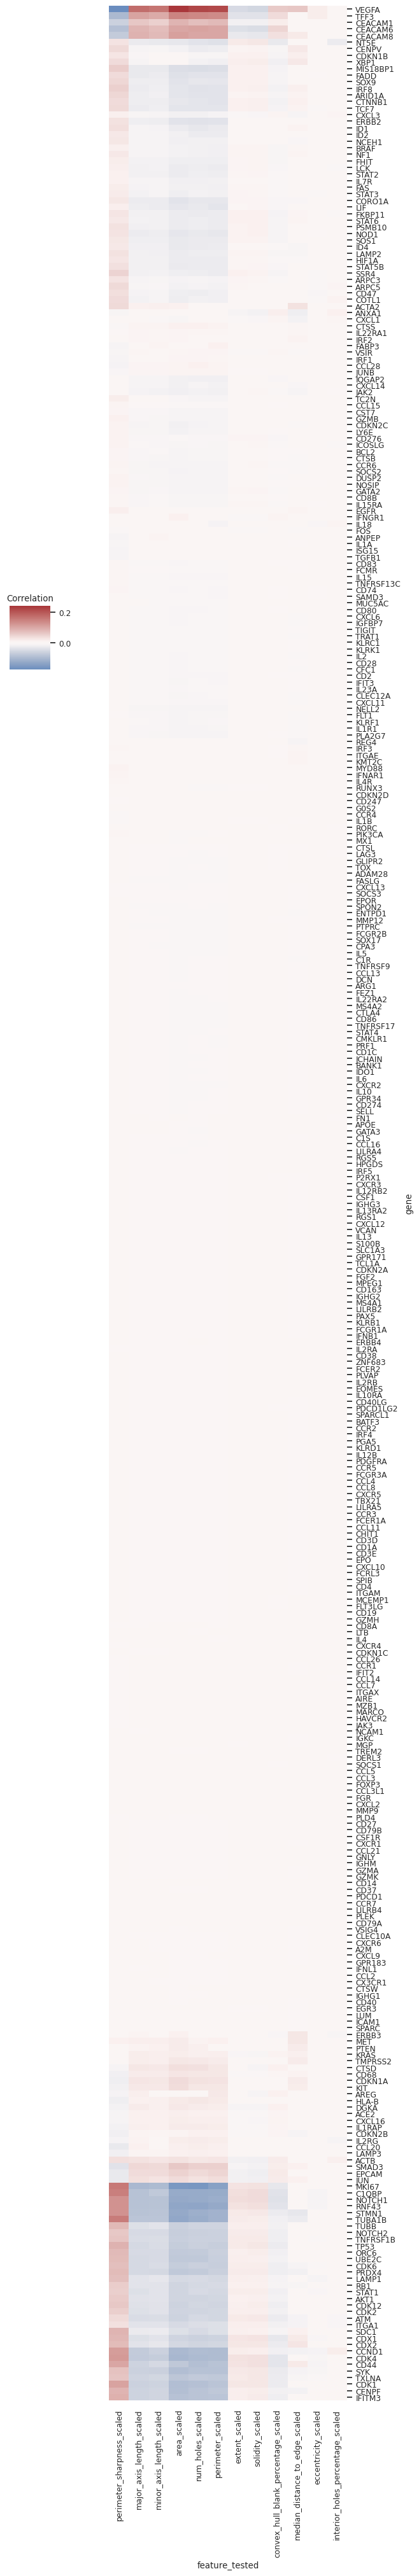

In [18]:
results_df = pd.concat(results)
results_filt = results_df[results_df['term'].isin(features_scaled)]
correlation_df = results_filt.query('q_val < 0.05').pivot(index='gene', columns='feature_tested', values='Estimate').fillna(0.)
clustergrid = plot_correlation_clustermap(
    df_corr=correlation_df,
    output_path=None,
    # top_n_genes=100, # Only plot the top 100 genes
    figsize=(6, 50),
    yticklabels=True # Show gene names on the y-axis
)

In [ ]:
import joblib
joblib.dump(results, '../../scratch/results.pkl')

['results.pkl']

## CCA

In [ ]:
from sklearn.cross_decomposition import PLSCanonical, PLSSVD


# Gene expression (cells × genes)
X = pb_malignant_PDO.X
if not isinstance(X, np.ndarray):
    X = X.toarray()

# Morphological features (cells × morphology_features)
Y = pb_malignant_PDO.obsm['morphology']

# Feature names
genes = np.array(pb_malignant_PDO.var_names)
morph_features = np.array(df_morph.columns)

# Scale both modalities
X_scaled = StandardScaler().fit_transform(X)
Y_scaled = StandardScaler().fit_transform(Y)


pls_svd = PLSSVD(n_components=3)
pls_svd.fit(X_scaled, Y_scaled)

# Latent (projected) cell coordinates
X_scores, Y_scores = pls_svd.transform(X_scaled, Y_scaled)

# # Explained shared variance
# cov_explained = pls_svd.singular_values_**2 / np.sum(pls_svd.singular_values_**2)
# cov_explained = pd.Series(cov_explained, index=[f"C{i+1}" for i in range(pls_svd.n_components)])
# cov_explained

# # 📊 Plot — Shared covariance explained per component
# plt.figure(figsize=(5, 3))
# plt.bar(cov_explained.index, cov_explained.values)
# plt.ylabel("Fraction of shared covariance")
# plt.title("Shared variance explained per component (PLSSVD)")
# plt.show()

# 4️⃣ Cross-modal correlations
corrs = [np.corrcoef(X_scores[:, i], Y_scores[:, i])[0, 1] 
         for i in range(pls_svd.n_components)]
corrs = pd.Series(corrs, index=[f"C{i+1}" for i in range(pls_svd.n_components)])
corrs

# Top genes per component
def top_features(weights, names, comp_idx, n=10):
    w = weights[:, comp_idx]
    idx = np.argsort(np.abs(w))[::-1][:n]
    return pd.DataFrame({
        "feature": names[idx],
        "weight": w[idx]
    })

top_genes = {f"C{i+1}": top_features(pls_svd.x_weights_, genes, i) 
             for i in range(pls_svd.n_components)}

# Top morphology features per component
top_morph = {f"C{i+1}": top_features(pls_svd.y_weights_, morph_features, i) 
             for i in range(pls_svd.n_components)}

# 🧬 Example — show top 10 features for the first component
print("Top genes driving component 1:")
display(top_genes["C1"])

print("Top morphology features driving component 1:")
display(top_morph["C1"])


# 📊 Plot — Top features per modality (component 1)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].barh(top_genes["C1"]["feature"], top_genes["C1"]["weight"])
axes[0].invert_yaxis()
axes[0].set_title("Top Genes (Component 1)")

axes[1].barh(top_morph["C1"]["feature"], top_morph["C1"]["weight"])
axes[1].invert_yaxis()
axes[1].set_title("Top Morphology Features (Component 1)")

plt.tight_layout()
plt.show()

# 6️⃣ Cross-component relationships
# How well do the gene and morphology components align?

corr_matrix = pd.DataFrame({
    f"Y_comp{i+1}": [np.corrcoef(X_scores[:, j], Y_scores[:, i])[0, 1]
                     for j in range(pls_svd.n_components)]
    for i in range(pls_svd.n_components)
}, index=[f"X_comp{j+1}" for j in range(pls_svd.n_components)])

corr_matrix

# 📊 Heatmap of cross-component correlations
plt.figure(figsize=(5, 4))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Cross-modal latent component correlations (PLSSVD)")
plt.show()

# 7️⃣ Joint latent visualization
plt.figure(figsize=(6, 6))
plt.scatter(X_scores[:, 0], Y_scores[:, 0], alpha=0.5)
plt.xlabel("Gene Expression Axis 1")
plt.ylabel("Morphology Axis 1")
plt.title("Shared latent structure (PLSSVD Component 1)")
plt.show()